# LMN Attack Accuracy Sweep
Run LMN attacks and visualize accuracy over environmental variation.

## Reproduce this notebook
1. Install dependencies from `pypuf/requirements.txt`.
2. Open this file in Jupyter.
3. Run each cell sequentially to generate the models and plots.

## Example output
![Representative output](../USE_CASE/graphs_metrics/FeedForwardArbiterPUF_metrics_vs_temperature.png)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_environmental_heatmap(
    accuracies,
    temp_range,
    vdd_range,
    puf_name,
    attack_name,
    save_full_grid=True,
    save_summary=True
):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(accuracies, cmap="viridis", interpolation='nearest', origin='lower')
    
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Model Accuracy", rotation=-90, va="bottom")

    ax.set_xticks(np.arange(len(vdd_range)))
    ax.set_yticks(np.arange(len(temp_range)))
    ax.set_xticklabels(vdd_range)
    ax.set_yticklabels(temp_range)
    ax.set_xlabel("Vdd (V)")
    ax.set_ylabel("Temperature (°C)")

    ax.set_title(f"{attack_name} Accuracy vs. Environment\nTarget: {puf_name}")
    plt.tight_layout()
    plt.show()

    # ==============================
    # 🔹 FULL GRID CSV (per PUF)
    # ==============================
    if save_full_grid:
        rows = []
        for i, T in enumerate(temp_range):
            for j, V in enumerate(vdd_range):
                rows.append({
                    "PUF_Type": puf_name,
                    "Attack_Type": attack_name,
                    "Temperature": T,
                    "Voltage": V,
                    "Accuracy": float(accuracies[i, j])
                })

        df_full = pd.DataFrame(rows)

        full_csv_name = f"{puf_name}_master_accuracy.csv"

        if os.path.exists(full_csv_name):
            df_full.to_csv(full_csv_name, mode='a', header=False, index=False)
        else:
            df_full.to_csv(full_csv_name, mode='w', header=True, index=False)

        print(f"Saved full grid accuracy to {full_csv_name}")

    # ==============================
    # 🔹 SUMMARY STATS (ALL PUFs)
    # ==============================
    if save_summary:
        flat_acc = accuracies.flatten()

        mean_acc = np.mean(flat_acc)
        std_acc = np.std(flat_acc)
        min_acc = np.min(flat_acc)
        max_acc = np.max(flat_acc)

        summary_row = {
            "PUF_Type": puf_name,
            "Attack_Type": attack_name,
            "Mean_Accuracy": mean_acc,
            "Std_Accuracy": std_acc,
            "Min_Accuracy": min_acc,
            "Max_Accuracy": max_acc,
            "Num_Grid_Points": len(flat_acc)
        }

        df_summary = pd.DataFrame([summary_row])

        summary_csv_name = "ALL_PUF_attack_summary.csv"

        if os.path.exists(summary_csv_name):
            df_summary.to_csv(summary_csv_name, mode='a', header=False, index=False)
        else:
            df_summary.to_csv(summary_csv_name, mode='w', header=True, index=False)

        print(f"Saved summary stats to {summary_csv_name}")
        print(f"Mean: {mean_acc:.4f}, Std: {std_acc:.4f}")


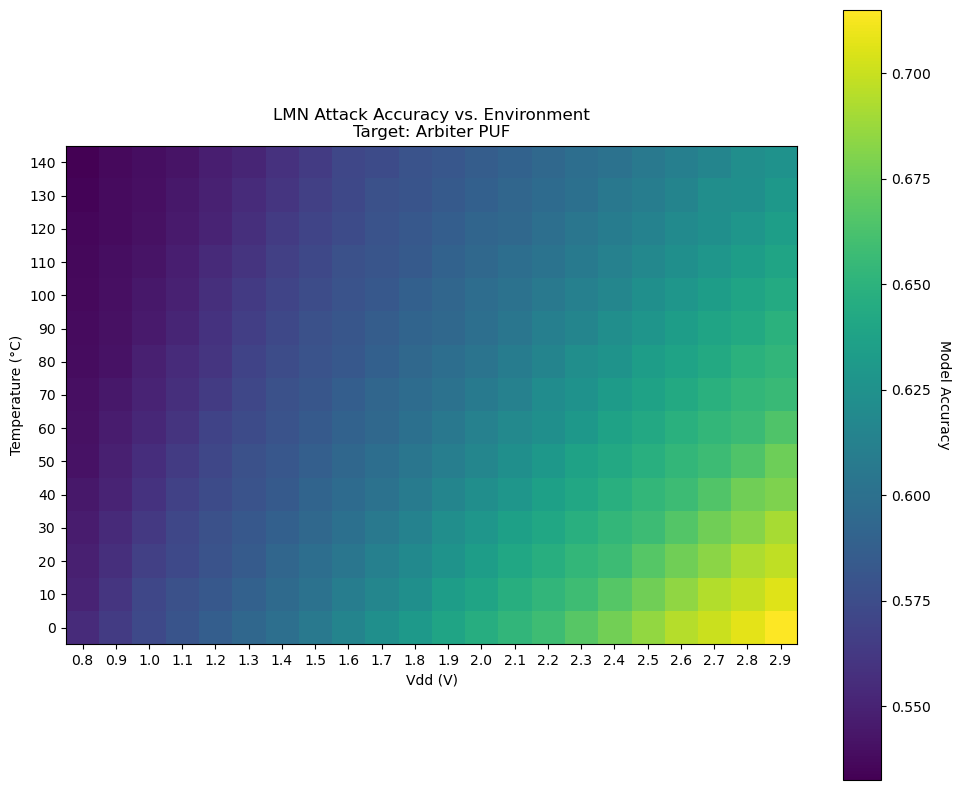

Saved full grid accuracy to Arbiter PUF_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.6027, Std: 0.0411


In [2]:
from pypuf.simulation import ArbiterPUF
from pypuf.io import ChallengeResponseSet
from pypuf.attack import LMNAttack  # [cite: 32]
from pypuf.metrics import similarity

# 1. Setup
n_bits, puf_seed = 64, 123
nom_temp, nom_vdd = 25.0, 1.2
n_train, n_test = 50000, 2000
temp_range = np.arange(0, 150, 10)
vdd_range = np.round(np.arange(0.8, 3.00, 0.1), 2)

# 2. Train at Nominal (Golden Point)
p_nom = ArbiterPUF(n=n_bits, seed=puf_seed, noisiness=0.05, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed=puf_seed)

# LMN Attack: (crps, deg) [cite: 32]
# Using deg=1 for faster computation; deg=2 can be used for higher accuracy at the cost of time [cite: 18, 19]
model = LMNAttack(train_crps, deg=1).fit() # [cite: 22, 23, 61]
model.temperature, model.vdd = nom_temp, nom_vdd

# 3. Environmental Sweep
acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = ArbiterPUF(n=n_bits, seed=puf_seed, temperature=t, vdd=v)
        
        # similarity() measures how well the Fourier model matches the shifted device [cite: 24, 30]
        # We use seed=4 to generate the evaluation CRPs per documentation [cite: 30]
        acc_grid[i, j] = similarity(p_eval, model, seed=4, N=n_test)[0] 

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Arbiter PUF", "LMN Attack")

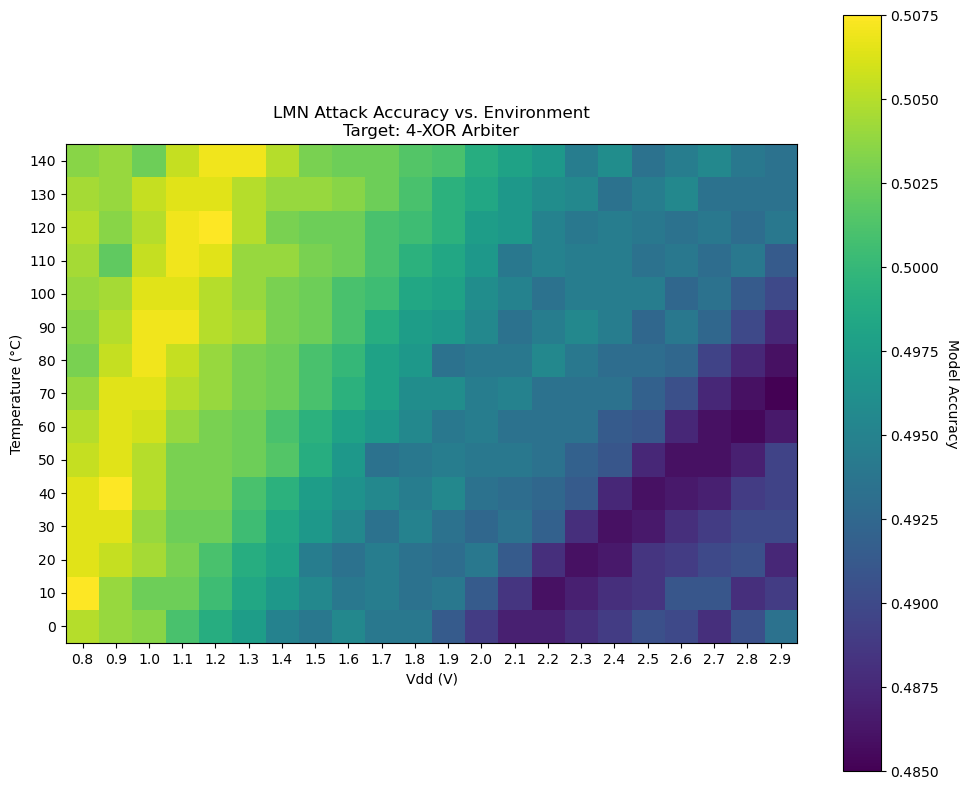

Saved full grid accuracy to 4-XOR Arbiter_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.4970, Std: 0.0061


In [3]:
from pypuf.simulation import XORArbiterPUF

k = 4
p_nom = XORArbiterPUF(n=n_bits, k=k, seed=puf_seed, noisiness=0.05, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=150000, seed=puf_seed)

# LMN Attack: Approximating the XOR'ed delay paths spectral density
model = LMNAttack(train_crps, deg=1).fit() #[cite: 23, 32]
model.temperature, model.vdd = nom_temp, nom_vdd

acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = XORArbiterPUF(n=n_bits, k=k, seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=4, N=n_test)[0] #[cite: 30]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, f"{k}-XOR Arbiter", "LMN Attack")

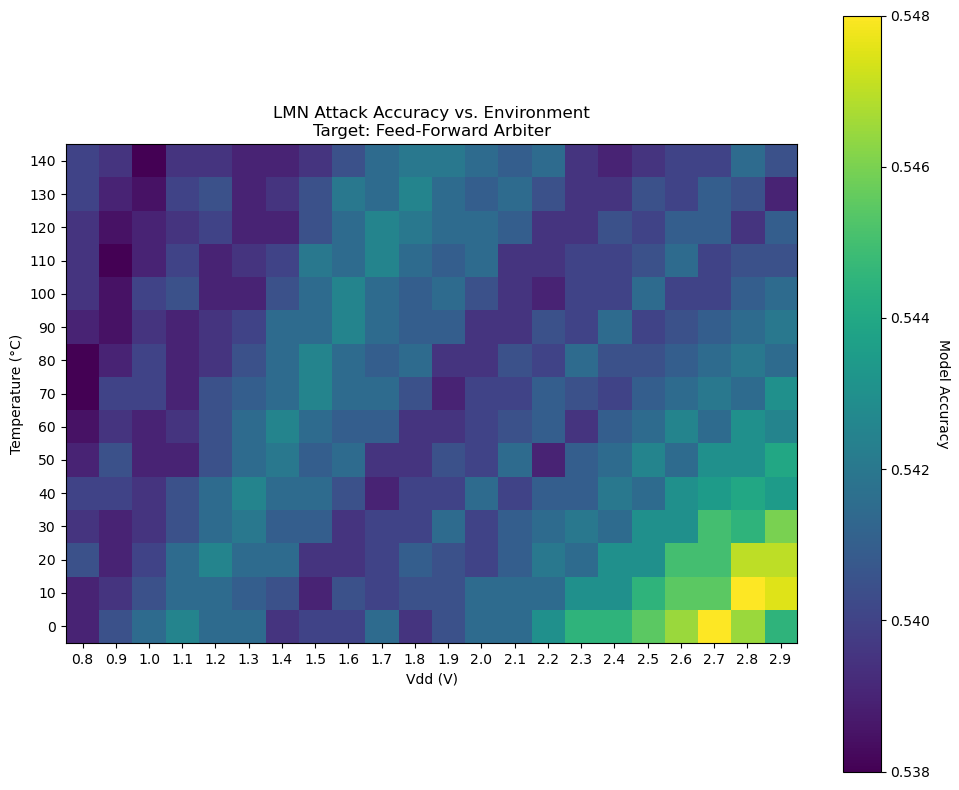

Saved full grid accuracy to Feed-Forward Arbiter_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.5409, Std: 0.0017


In [4]:
from pypuf.simulation import FeedForwardArbiterPUF

ff_config = [(10, 20), (30, 40)]
p_nom = FeedForwardArbiterPUF(n=n_bits, ff=ff_config, seed=puf_seed, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed=puf_seed)

model = LMNAttack(train_crps, deg=1).fit() #[cite: 32]
model.temperature, model.vdd = nom_temp, nom_vdd

acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = FeedForwardArbiterPUF(n=n_bits, ff=ff_config, seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=4, N=n_test)[0] 

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Feed-Forward Arbiter", "LMN Attack")

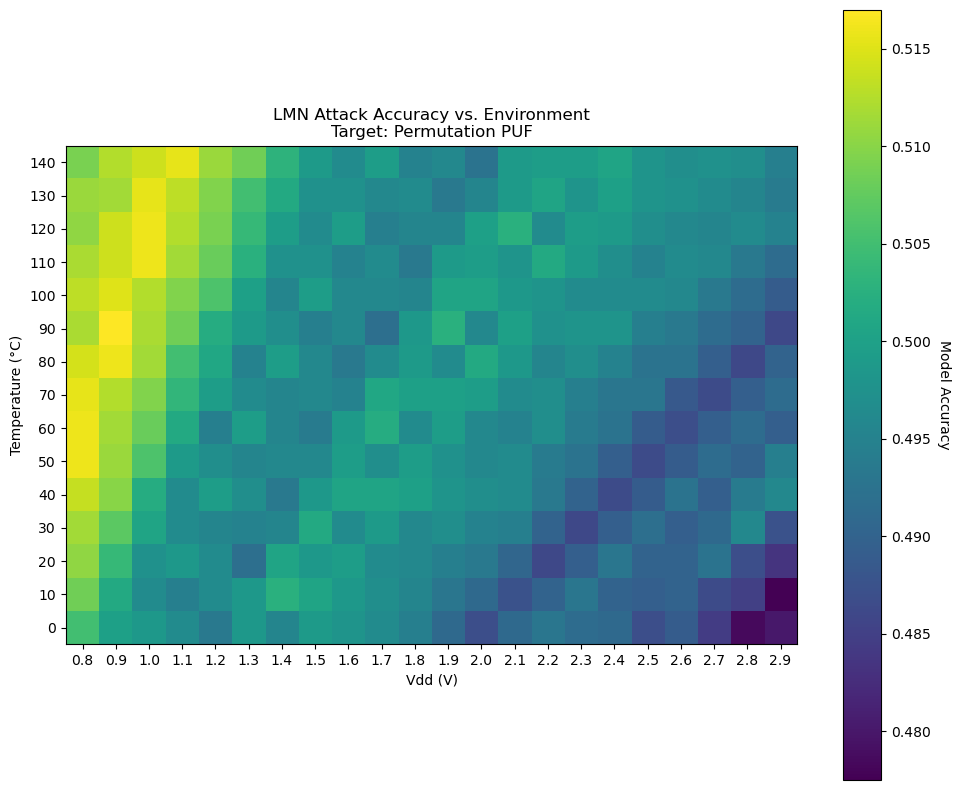

Saved full grid accuracy to Permutation PUF_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.4978, Std: 0.0073


In [5]:
from pypuf.simulation import PermutationPUF
from pypuf.io import ChallengeResponseSet
from pypuf.attack import LMNAttack 
from pypuf.metrics import similarity

# 1. Setup Data Generation at Nominal Conditions
# Permutation PUFs utilize k-length blocks to shuffle bit mappings
p_nom = PermutationPUF(n=n_bits, seed=puf_seed, temperature=nom_temp, vdd=nom_vdd, k=8)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed=puf_seed)

# 2. Run LMN Attack
# Degree 1 approximations are computationally linear and highly effective 
# This computes an approximation of the Fourier spectrum of the underlying function [cite: 34, 35]
model = LMNAttack(train_crps, deg=1).fit() 

# Ensure the model knows it was trained at nominal conditions for physics evaluation
model.temperature, model.vdd = nom_temp, nom_vdd

# 3. Environmental Sweep Evaluation
acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        # Create target instance with shifted environmental parameters
        p_eval = PermutationPUF(n=n_bits, seed=puf_seed, temperature=t, vdd=v, k=8)
        
        # similarity() compares the fixed LMN model against the shifted device [cite: 30]
        # Similarity returns an array; take [0] for the scalar accuracy
        acc_grid[i, j] = similarity(p_eval, model, seed=4, N=n_test)[0]

# 4. Visualize Results
plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Permutation PUF", "LMN Attack")

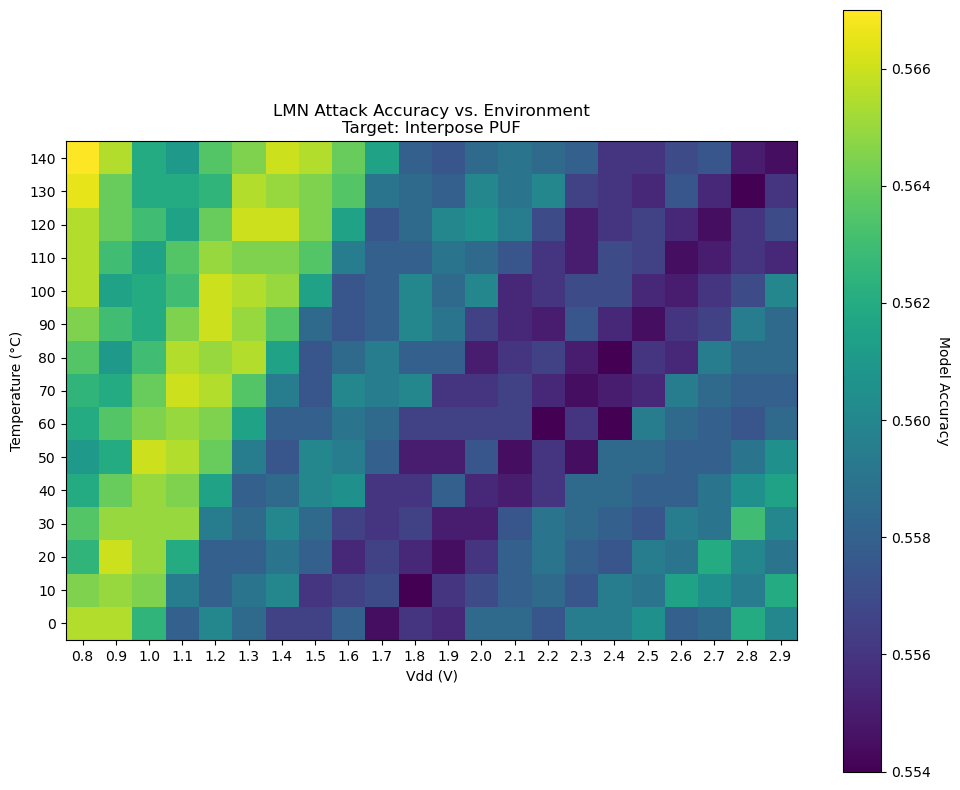

Saved full grid accuracy to Interpose PUF_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.5594, Std: 0.0033


In [6]:
from pypuf.simulation import InterposePUF

# Setup for Interpose (Up/Down chain split)
p_nom = InterposePUF(n=n_bits, k_up=2, k_down=2, seed=puf_seed, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=300000, seed=puf_seed) 

# LMN Attack fits a FourierSimulation object based on CRP data [cite: 32, 61]
model = LMNAttack(train_crps, deg=1).fit() 
model.temperature, model.vdd = nom_temp, nom_vdd

acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = InterposePUF(n=n_bits, k_up=2, k_down=2, seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=4, N=n_test)[0] 

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Interpose PUF", "LMN Attack")